In [ ]:
! OMP_NUM_THREADS=4 DP_INTRA_OP_PARALLELISM_THREADS=4 DP_INTER_OP_PARALLELISM_THREADS=2 dp train input.json

/Users/agneskatai/miniforge3/envs/deepmd/lib/python3.12/site-packages/horovod/common/util.py:258: UserWarning: Framework tensorflow installed with version 2.15.0 but found version 2.18.0.
             This can result in unexpected behavior including runtime errors.
             Reinstall Horovod using `pip install --no-cache-dir` to build with the new version.
  warnings.warn(get_version_mismatch_message(name, version, installed_version))
[2026-09-28 20:11:54,526] DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
[2026-09-28 20:11:54,534] DEEPMD WARNING You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.
I0000 00:00:1790640714.596700  561908 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
[2026-09-28 20:11:56,505] DEEPMD INFO    Neighbor statistics: training data with minimal neighbor distance: 1.233689
[2026-09-28 20:11:56,505]

In [3]:
! head -n 2 lcurve.out && tail -n 2 lcurve.out

# step       rmse_val    rmse_trn    rmse_e_val  rmse_e_trn    rmse_f_val  rmse_f_trn    rmse_v_val  rmse_v_trn   lr      
# If there is no available reference data, rmse_*_{val,trn} will print nan
   9800      4.63e-01    4.47e-01      6.73e-03    7.83e-03      2.89e-01    2.89e-01      2.59e-02    2.39e-02    4.3e-08
  10000      5.33e-01    3.28e-01      6.00e-03    4.71e-03      2.59e-01    2.31e-01      3.42e-02    1.64e-02    3.5e-08


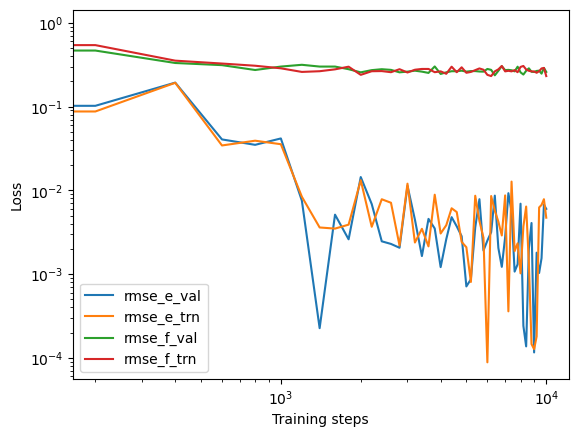

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

with open("lcurve.out") as f:
    headers = f.readline().split()[1:]
lcurve = pd.DataFrame(np.loadtxt("lcurve.out"), columns=headers)
legends = ["rmse_e_val", "rmse_e_trn", "rmse_f_val", "rmse_f_trn"]
for legend in legends:
    plt.loglog(lcurve["step"], lcurve[legend], label=legend)
plt.legend()
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.show()

In [6]:
! dp freeze -o graph.pb

To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
/Users/agneskatai/miniforge3/envs/deepmd/lib/python3.12/site-packages/horovod/common/util.py:258: UserWarning: Framework tensorflow installed with version 2.15.0 but found version 2.18.0.
             This can result in unexpected behavior including runtime errors.
             Reinstall Horovod using `pip install --no-cache-dir` to build with the new version.
  warnings.warn(get_version_mismatch_message(name, version, installed_version))
I0000 00:00:1790633679.645399  438477 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
[2026-09-28 18:14:40,654] DEEPMD INFO    The following nodes will be frozen: ['model_attr/tmap', 'model_attr/model_type', 'fitting_attr/dfparam', 'o_atom_virial', 'o_force', 'd

In [7]:
import dpdata

training_systems = dpdata.LabeledSystem("../data/training_data", fmt="deepmd/npy")

predict = training_systems.predict("graph.pb")


To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
I0000 00:00:1790633776.767164  245206 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
You can use the environment variable DP_INFER_BATCH_SIZE tocontrol the inference batch size (nframes * natoms). The default value is 1024.


[]

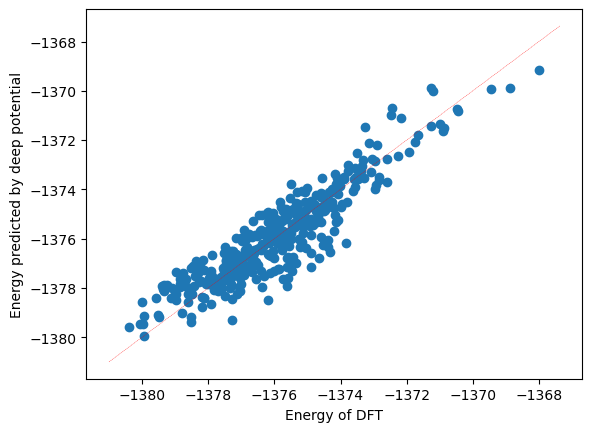

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(training_systems["energies"], predict["energies"])

x_range = np.linspace(plt.xlim()[0], plt.xlim()[1])

plt.plot(x_range, x_range, "r--", linewidth=0.25)
plt.xlabel("Energy of DFT")
plt.ylabel("Energy predicted by deep potential")
plt.plot()